# Does size matter? Exploring the relationship between population size, growth, and national happiness 
### Social Data Analysis and Visualization — Final Project
**DTU · Spring 2026**

---

> **Website:** [fridapfrandsen.github.io](https://fridapfrandsen.github.io)
>
> **Group:** Karen Stentoft (s253843), Frida Pilegaard Frandsen (s253842)
>
> **Date:** 12th May 2026

---

## Indholdsfortegnelse

1. [Motivation](#1-motivation)
2. [Basic Stats & Data Cleaning](#2-basic-stats--data-cleaning)
3. [Data Analysis](#3-data-analysis)
4. [Genre](#4-genre)
5. [Visualizations](#5-visualizations)
6. [Discussion](#6-discussion)
7. [Contributions](#7-contributions)
8. [References](#8-references)

---
## 1. Motivation
<a id='1-motivation'></a>

### 1.1 The data

Beskriv hvilket/hvilke datasæt I bruger. Hvad indeholder det? Hvorfra er det hentet?

- **Kilde:** ...
- **Format:** ...
- **Tidsperiode:** ...

### 1.2 Why this data?

When looking at the World Happiness Report, a pattern quickly stands out: the countries that consistently rank highest (Finland, Denmark, Iceland, Norway, New Zealand) are all relatively small nations. Is this a coincidence, or does it reflect something fundamental about the relationship between the size of a society and its happiness? This observation is the starting point for our project. We want to investigate whether there is a systematic relationship between a country's population size (and its development over time) and its position on the happiness scale - and if so, what might explain it.

### 1.3 Goal for the end user's experience

We want to take the reader on a data-driven journey that starts with a simple observation: 'small countries seem happier', and gradually reveals a more nuanced picture. Along the way, we will explore whether it is size itself, population growth rate, or underlying factors such as GDP and social security that drive the pattern. The end result should leave the reader with a new, data-informed way of thinking about what shapes a nation's happiness.

---
## 2. Basic Stats & Data Cleaning
<a id='2-basic-stats--data-cleaning'></a>

In [16]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.gridspec as gridspec
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Plot-stil
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')
%matplotlib inline

In [2]:
# Read data
df_happiness_raw = pd.read_csv('data/world_happiness_combined.csv')
df_population_raw = pd.read_csv('data/Population_development.csv')

print(f"Happiness raw shape:   {df_happiness_raw.shape}")
print(f"Population raw shape:  {df_population_raw.shape}")

Happiness raw shape:   (1231, 12)
Population raw shape:  (266, 71)


### 2.1 Data Cleaning and Overview

*Kort beskrivelse af hvilket datacleaning vi har lavet inden vi gemte dem som endelige csv-filer*

#### 2.1.1 Country name matching
We have 2 different datasets which we combined. 
In order to do this we first did a manuel mapping of the country names.

In [4]:
name_map = {
    'Congo':                      'Congo, Rep.',
    'Congo (Brazzaville)':        'Congo, Rep.',
    'Congo (Kinshasa)':           'Congo, Dem. Rep.',
    'Czech Republic':             'Czechia',
    'Egypt':                      'Egypt, Arab Rep.',
    'Eswatini, Kingdom of':       'Eswatini',
    'Gambia':                     'Gambia, The',
    'Hong Kong':                  'Hong Kong SAR, China',
    'Hong Kong S.A.R. of China':  'Hong Kong SAR, China',
    'Hong Kong S.A.R., China':    'Hong Kong SAR, China',
    'Iran':                       'Iran, Islamic Rep.',
    'Ivory Coast':                "Cote d'Ivoire",
    'Kyrgyzstan':                 'Kyrgyz Republic',
    'Laos':                       'Lao PDR',
    'Macedonia':                  'North Macedonia',
    'Russia':                     'Russian Federation',
    'Slovakia':                   'Slovak Republic',
    'Somalia':                    'Somalia, Fed. Rep.',
    'Somaliland Region':          'Somalia, Fed. Rep.',
    'Somaliland region':          'Somalia, Fed. Rep.',
    'South Korea':                'Korea, Rep.',
    'Swaziland':                  'Eswatini',
    'Syria':                      'Syrian Arab Republic',
    'Taiwan':                     None,   # ikke i World Bank data
    'Taiwan Province of China':   None,
    'Trinidad & Tobago':          'Trinidad and Tobago',
    'Turkey':                     'Turkiye',
    'Venezuela':                  'Venezuela, RB',
    'Vietnam':                    'Viet Nam',
    'Palestinian Territories':    'West Bank and Gaza',
    'North Cyprus':               None,
    'Northern Cyprus':            None,
    'Puerto Rico':                'Puerto Rico (US)',
    'Yemen':                      'Yemen, Rep.',
    'Kosovo':                     'Kosovo',
}

df_h = df_happiness_raw.copy()
df_h['Country_matched'] = df_h['Country'].apply(lambda x: name_map.get(x, x))

# Removing countries that doesn't appear in both datasets 
df_h = df_h[df_h['Country_matched'].notna() & (df_h['Country_matched'] != 'xx')].copy()

region_mode = (df_h.groupby('Country_matched')['Region']
               .agg(lambda x: x.mode()[0]).reset_index()
               .rename(columns={'Country_matched': 'Country_matched', 'Region': 'Region'}))
df_h = df_h.drop(columns='Region').merge(region_mode, on='Country_matched')

print(f"Number of countries after name matching and cleaning: {df_h['Country_matched'].nunique()}")

Number of countries after name matching and cleaning: 162


#### 2.1.2 Happiness Data
We now clean the dataset regarding the happiness of the countries.

We have a dataset with happiness score for each country from the years 2015 to 2022. 
In order to get a more stabil overview of the happiness, we take the mean across the years and use this as the happiness score for the respective country.
We do the same regarding the other features in the dataset.

In [19]:
feature_cols = [
    'Happiness Score', 'GDP per Capita', 'Social Support',
    'Healthy Life Expectancy', 'Freedom',
    'Perceptions of Corruption', 'Generosity', 'Dystopia Residual'
]

df_happiness_avg = (
    df_h.groupby(['Country_matched', 'Region'])[feature_cols]
    .mean()
    .reset_index()
    .rename(columns={'Country_matched': 'Country'})
    .round(4)
)

print(f"Shape: {df_happiness_avg.shape}  →  {df_happiness_avg['Country'].nunique()} countries")
df_happiness_avg.head(5)

Shape: (162, 10)  →  162 countries


,Country,Region,Happiness Score,GDP per Capita,Social Support,Healthy Life Expectancy,Freedom,Perceptions of Corruption,Generosity,Dystopia Residual
0,Afghanistan,South Asia,3.1322,2.2127,0.3728,13.3307,0.1710,0.2691,0.1537,1.8190
1,Albania,Central and Eastern Europe,4.8452,3.1338,0.7236,17.7956,0.4922,0.2552,0.1131,1.8211
2,Algeria,Middle East and North Africa,5.4190,3.1635,0.9933,16.9848,0.2481,0.2960,0.0330,2.3726
3,Angola,Sub-Saharan Africa,3.8723,0.7984,0.9384,0.1339,0.0274,0.0716,0.1053,1.8862
4,Argentina,Latin America and Caribbean,6.2710,3.3650,1.1944,17.7838,0.5778,0.2603,0.0207,2.5007


Basic stats for the happiness data:

In [9]:
df_happiness_avg[feature_cols].describe().round(3)

,Happiness Score,GDP per Capita,Social Support,Healthy Life Expectancy,Freedom,Perceptions of Corruption,Generosity,Dystopia Residual
count,162.000,162.000,162.000,162.000,162.000,162.000,162.000,162.000
mean,5.403,2.982,0.983,15.946,0.512,0.277,0.156,2.094
std,1.099,0.977,0.240,6.339,0.144,0.068,0.119,0.477
min,3.132,0.078,0.064,0.134,0.027,0.072,-0.072,0.650
25%,4.533,2.526,0.847,15.020,0.427,0.249,0.064,1.809
50%,5.378,3.127,1.004,17.051,0.535,0.270,0.149,2.141
75%,6.181,3.554,1.185,17.836,0.609,0.297,0.220,2.430
max,7.645,9.672,1.343,70.600,0.854,0.825,0.642,3.019


#### 2.1.3 Population data

Next we look at the population data. We have the growth in population from the years 1980 to 2022.

We remove the regions, such that we only have individual conutries in the data.

In [20]:
year_cols = [str(y) for y in range(1980, 2023)]

region_keywords = [
    'income', ' & ', 'Africa Eastern', 'Africa Western',
    'World', 'OECD', 'IDA', 'IBRD', 'Arab World', 'dividend',
    'states', 'Not classified', 'Heavily', 'Fragile', 'Euro area',
    'Sub-Saharan', 'North America', 'South Asia', 'East Asia',
    'Latin America', 'Middle East', 'Central Europe', 'Baltics',
    'Pacific island', 'Caribbean small', 'Other small'
]

def is_region(name):
    return any(kw in name for kw in region_keywords)

df_population = (
    df_population_raw[~df_population_raw['Country Name'].apply(is_region)]
    [['Country Name'] + year_cols]
    .copy()
    .rename(columns={'Country Name': 'Country'})
)
df_population[year_cols] = df_population[year_cols].apply(pd.to_numeric, errors='coerce')

print(f"Shape: {df_population.shape}  →  {df_population['Country'].nunique()} countries, {len(year_cols)} years (1980–2022)")
df_population[['Country', '1980', '1990', '2000', '2010', '2022']].head(5)

Shape: (219, 44)  →  219 countries, 43 years (1980–2022)


,Country,1980,1990,2000,2010,2022
0,Aruba,59909.0,62753.0,90588.0,101838.0,107310.0
2,Afghanistan,13169311.0,12045660.0,20130327.0,28284089.0,40578842.0
4,Angola,8133872.0,11626360.0,16194869.0,23294825.0,35635029.0
5,Albania,2671997.0,3286542.0,3089027.0,2913021.0,2451636.0
6,Andorra,35782.0,52597.0,65685.0,80706.0,79705.0


Basic stats for the population data:

In [10]:
df_population[['1980', '1990', '2000', '2010', '2022']].describe().map(lambda x: f"{x:,.0f}")

,1980,1990,2000,2010,2022
count,218,219,219,219,219
mean,"23,994,918","28,398,113","33,071,605","37,787,968","43,598,846"
std,"91,924,168","108,615,708","126,039,238","142,110,045","161,557,150"
min,"7,366","8,798","9,544","10,043","9,992"
25%,"360,271","494,536","621,266","725,444","827,912"
50%,"3,672,286","4,391,236","5,140,037","5,737,971","6,730,654"
75%,"11,465,468","13,265,856","17,168,446","22,332,880","26,980,808"
max,"981,235,000","1,135,185,000","1,262,645,000","1,337,705,000","1,425,423,212"


#### 2.1.4 Combined data

At last we combine the two data sets.

We merge the dataframes on the name of the country. Furthermore we add some columns in order to help with further analysis:
- `Pop_2022` — Latest population
- `Pop_1980` — Population in 1980
- `Pop_growth_pct` — The growth in population (%)
- `Log_Pop_2022` — log10 of the population size

In [21]:
df_combined = pd.merge(df_happiness_avg, df_population, on='Country', how='inner')

df_combined['Pop_2022']       = df_combined['2022']
df_combined['Pop_1980']       = df_combined['1980']
df_combined['Pop_growth_pct'] = ((df_combined['2022'] - df_combined['1980']) / df_combined['1980'] * 100).round(2)
df_combined['Log_Pop_2022']   = np.log10(df_combined['2022']).round(4)

# Normalise a couple of inconsistent region names
region_remap = {
    'Southern Asia': 'South Asia',
    'Middle East and Northern Africa': 'Middle East and North Africa',
}
df_combined['Region']      = df_combined['Region'].replace(region_remap)
df_happiness_avg['Region'] = df_happiness_avg['Region'].replace(region_remap)


print(f"Shape: {df_combined.shape}  →  {df_combined['Country'].nunique()} countries")
df_combined[['Country', 'Region', 'Happiness Score', 'Pop_2022', 'Pop_growth_pct', 'Log_Pop_2022']].head(8)

Shape: (162, 57)  →  162 countries


,Country,Region,Happiness Score,Pop_2022,Pop_growth_pct,Log_Pop_2022
0,Afghanistan,South Asia,3.1322,40578842.0,208.13,7.6083
1,Albania,Central and Eastern Europe,4.8452,2451636.0,-8.25,6.3895
2,Algeria,Middle East and North Africa,5.4190,45477389.0,144.41,7.6578
3,Angola,Sub-Saharan Africa,3.8723,35635029.0,338.11,7.5519
4,Argentina,Latin America and Caribbean,6.2710,45407904.0,62.10,7.6571
5,Armenia,Central and Eastern Europe,4.6656,2969200.0,-4.45,6.4726
6,Australia,Australia and New Zealand,7.2436,26018721.0,77.09,7.4153
7,Austria,Western Europe,7.1794,9041851.0,19.77,6.9563


Basic stats of the combined data:

In [22]:
stat_cols = ['Happiness Score', 'GDP per Capita', 'Social Support', 'Freedom',
             'Pop_2022', 'Pop_growth_pct', 'Log_Pop_2022']
df_combined[stat_cols].describe().round(3)

,Happiness Score,GDP per Capita,Social Support,Freedom,Pop_2022,Pop_growth_pct,Log_Pop_2022
count,162.000,162.000,162.000,162.000,1.620000e+02,161.000,162.000
mean,5.403,2.982,0.983,0.512,4.877310e+07,123.372,7.099
std,1.099,0.977,0.240,0.144,1.621413e+08,129.792,0.682
min,3.132,0.078,0.064,0.027,3.820030e+05,-27.040,5.582
25%,4.533,2.526,0.847,0.427,4.917631e+06,30.690,6.692
50%,5.378,3.127,1.004,0.535,1.124350e+07,96.030,7.051
75%,6.181,3.554,1.185,0.609,3.652507e+07,189.490,7.563
max,7.645,9.672,1.343,0.854,1.425423e+09,891.920,9.154


Distribution of countries in regions:

In [23]:
df_combined['Region'].value_counts().to_frame('Count')

,Count
Region,
Sub-Saharan Africa,43
Central and Eastern Europe,29
Latin America and Caribbean,24
Middle East and North Africa,20
Western Europe,20
Southeast Asia,9
South Asia,8
East Asia,5
Australia and New Zealand,2


### 2.2 Exploratory Data Analysis ???

Centrale pointer og plots fra den indledende dataudforskning:

In [ ]:
# EDA-plots — fx fordeling af nøglevariable
# fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# ...
# plt.tight_layout()
# plt.show()

---
## 3. Data Analysis
<a id='3-data-analysis'></a>

We now perform exploratory data analysis across four dimensions:
the distribution of happiness scores, individual feature distributions, regional patterns, and the relationship between population and happiness.

### 3.1 Happiness Score - Distribution

We first look at the distribution of the happiness score across the countries.

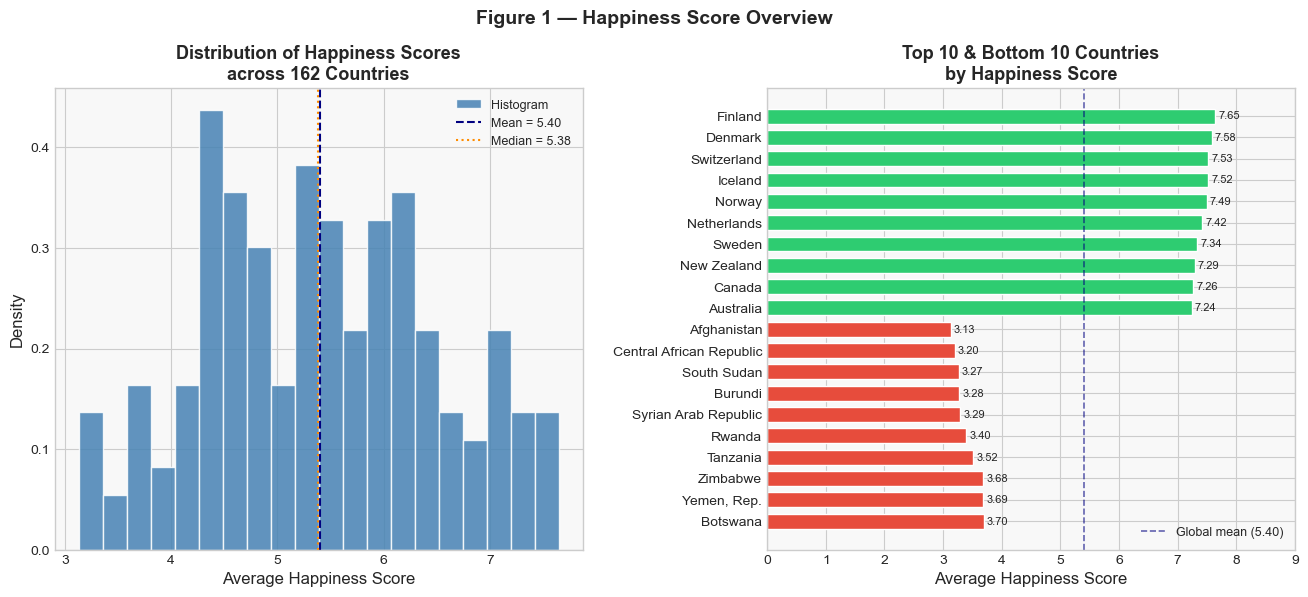

In [26]:
fig = plt.figure(figsize=(16, 6))
gs  = gridspec.GridSpec(1, 2, figure=fig, wspace=0.35)

ax1   = fig.add_subplot(gs[0])
scores = df_happiness_avg['Happiness Score'].dropna()
ax1.hist(scores, bins=20, color='steelblue', edgecolor='white', alpha=0.85,
         density=True, label='Histogram')
ax1.axvline(scores.mean(),   color='navy',       lw=1.5, ls='--',
            label=f'Mean = {scores.mean():.2f}')
ax1.axvline(scores.median(), color='darkorange',  lw=1.5, ls=':',
            label=f'Median = {scores.median():.2f}')
ax1.set_xlabel('Average Happiness Score', fontsize=12)
ax1.set_ylabel('Density', fontsize=12)
ax1.set_title('Distribution of Happiness Scores\nacross 162 Countries',
              fontsize=13, fontweight='bold')
ax1.legend(fontsize=9)

ax2      = fig.add_subplot(gs[1])
df_top   = df_happiness_avg.nlargest(10, 'Happiness Score')[['Country', 'Happiness Score']]
df_bot   = df_happiness_avg.nsmallest(10, 'Happiness Score')[['Country', 'Happiness Score']]
df_bars  = pd.concat([df_top, df_bot]).reset_index(drop=True)
bar_cols = ['#2ecc71'] * 10 + ['#e74c3c'] * 10
ax2.barh(df_bars['Country'], df_bars['Happiness Score'],
         color=bar_cols, edgecolor='white', height=0.7)
ax2.axvline(scores.mean(), color='navy', lw=1.2, ls='--', alpha=0.6,
            label=f"Global mean ({scores.mean():.2f})")
for i, (_, row) in enumerate(df_bars.iterrows()):
    ax2.text(row['Happiness Score'] + 0.05, i, f"{row['Happiness Score']:.2f}",
             va='center', fontsize=8)
ax2.invert_yaxis()
ax2.set_xlim(0, 9)
ax2.set_xlabel('Average Happiness Score', fontsize=12)
ax2.set_title('Top 10 & Bottom 10 Countries\nby Happiness Score',
              fontsize=13, fontweight='bold')
ax2.legend(fontsize=9)

plt.suptitle('Figure 1 — Happiness Score Overview', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## Skriv lidt om fordelingen. Fra Claude:

The distribution of average happiness scores is approximately bell-shaped with a slight negative skew — meaning
there are more countries clustered around the middle-to-upper range, but a long tail of low-scoring nations.
The mean (≈ 5.4) and median are very close, confirming the near-symmetry. Western Europe consistently dominates
the top 10, while Sub-Saharan Africa dominates the bottom 10.

### 3.2 Feature distributions

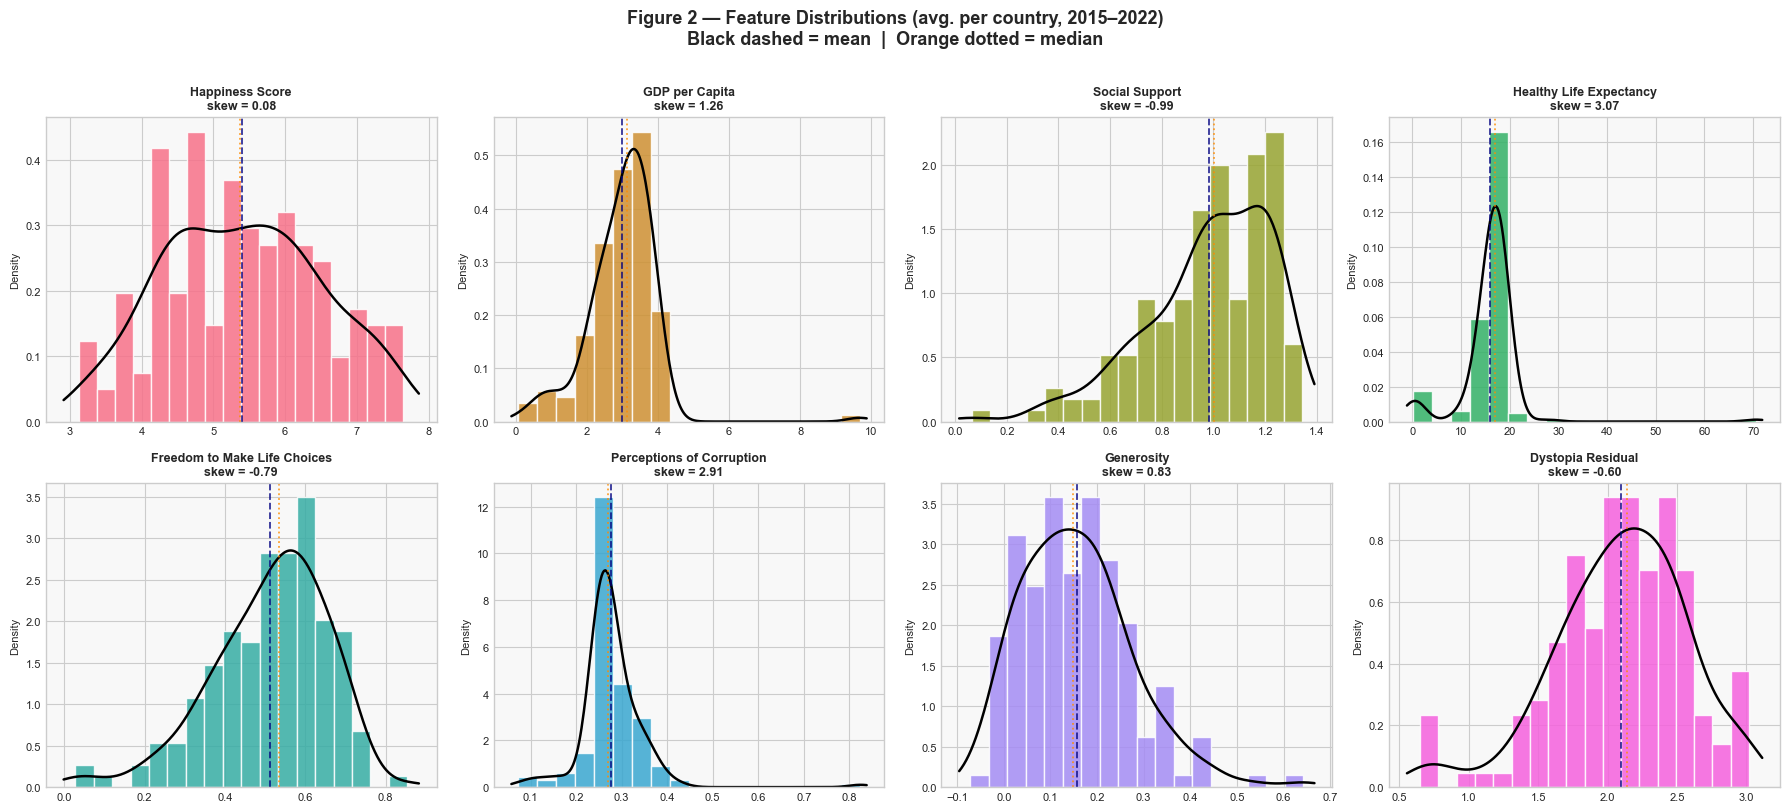

In [27]:
feat_labels = {
    'Happiness Score':           'Happiness Score',
    'GDP per Capita':            'GDP per Capita',
    'Social Support':            'Social Support',
    'Healthy Life Expectancy':   'Healthy Life Expectancy',
    'Freedom':                   'Freedom to Make Life Choices',
    'Perceptions of Corruption': 'Perceptions of Corruption',
    'Generosity':                'Generosity',
    'Dystopia Residual':         'Dystopia Residual',
}
colors_feat = sns.color_palette('husl', 8)
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, (feat, label) in enumerate(feat_labels.items()):
    ax  = axes[i]
    dat = df_happiness_avg[feat].dropna()
    ax.hist(dat, bins=18, color=colors_feat[i], edgecolor='white', alpha=0.85, density=True)
    kde_x = np.linspace(dat.min() - dat.std()*0.2, dat.max() + dat.std()*0.2, 300)
    ax.plot(kde_x, stats.gaussian_kde(dat)(kde_x), color='black', lw=1.8)
    ax.axvline(dat.mean(),   color='navy',       lw=1.3, ls='--', alpha=0.8)
    ax.axvline(dat.median(), color='darkorange',  lw=1.3, ls=':',  alpha=0.8)
    ax.set_title(f'{label}\nskew = {dat.skew():.2f}', fontsize=9, fontweight='bold')
    ax.set_ylabel('Density', fontsize=8)
    ax.tick_params(labelsize=8)

plt.suptitle(
    'Figure 2 — Feature Distributions (avg. per country, 2015–2022)\n'
    'Black dashed = mean  |  Orange dotted = median',
    fontsize=13, fontweight='bold', y=1.01
)
plt.tight_layout()
plt.show()

## Skriv lidt om fordelingerne. Fra Claude:


A few noteworthy observations:
- **GDP per Capita** is negatively skewed — most countries have moderate GDP, but a handful of very wealthy nations
  pull the distribution.
- **Generosity** is close to zero for many countries and near-symmetric, suggesting it contributes relatively little
  to cross-country differences in happiness.
- **Perceptions of Corruption** is tightly clustered at low values for most countries, with a long right tail for
  highly corrupt nations.
- **Social Support** and **Freedom** are among the most normally distributed features.

### 3.3 Happiness by region

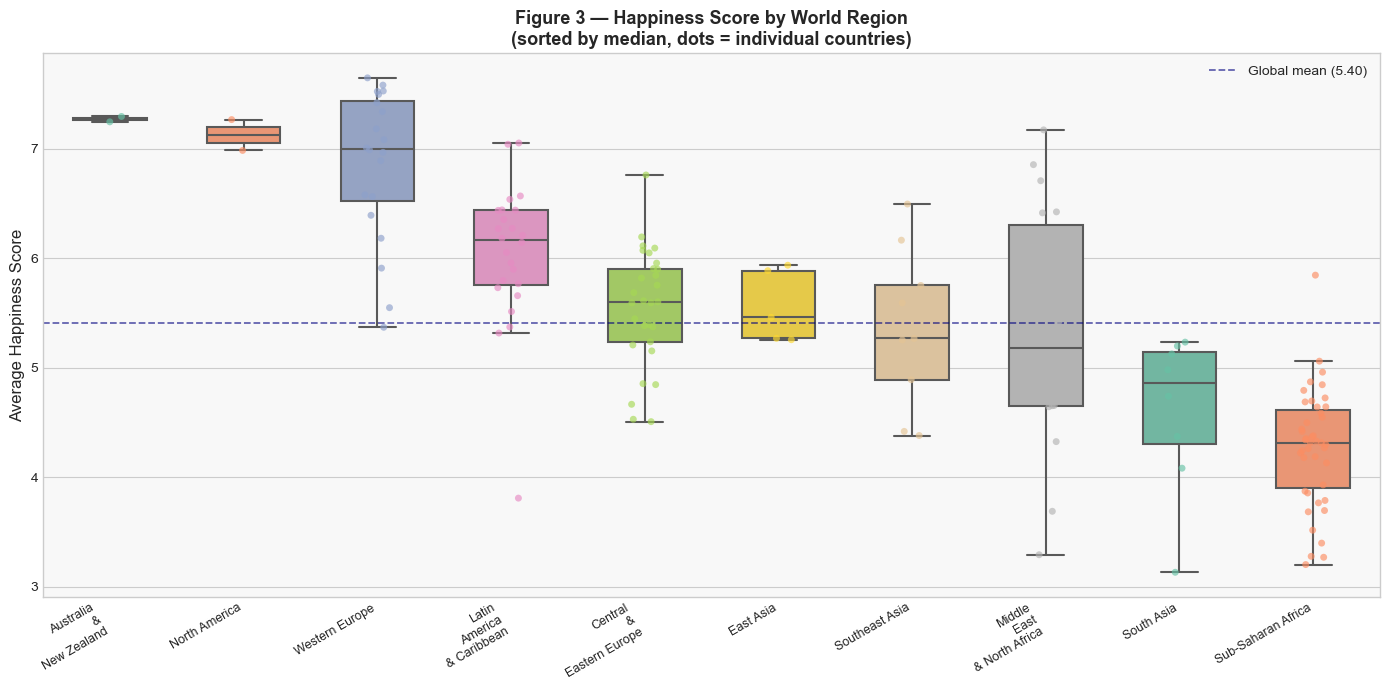

In [28]:
region_medians  = df_combined.groupby('Region')['Happiness Score'].median().sort_values(ascending=False)
ordered_regions = region_medians.index.tolist()

df_plot           = df_combined.copy()
df_plot['Region'] = pd.Categorical(df_plot['Region'], categories=ordered_regions, ordered=True)
df_plot           = df_plot.sort_values('Region')

fig, ax = plt.subplots(figsize=(14, 7))
sns.boxplot(data=df_plot, x='Region', y='Happiness Score', order=ordered_regions,
            palette='Set2', width=0.55, linewidth=1.5, fliersize=0, ax=ax)
sns.stripplot(data=df_plot, x='Region', y='Happiness Score', order=ordered_regions,
              palette='Set2', size=5, alpha=0.65, jitter=True, ax=ax)

ax.set_xticklabels(
    [r.replace(' and ', '\n& ').replace(' ', '\n', 1) if len(r) > 18 else r
     for r in ordered_regions],
    fontsize=9, rotation=30, ha='right'
)
ax.set_xlabel('')
ax.set_ylabel('Average Happiness Score', fontsize=12)
ax.set_title(
    'Figure 3 — Happiness Score by World Region\n(sorted by median, dots = individual countries)',
    fontsize=13, fontweight='bold'
)
ax.axhline(df_combined['Happiness Score'].mean(), color='navy', lw=1.3, ls='--', alpha=0.6,
           label=f"Global mean ({df_combined['Happiness Score'].mean():.2f})")
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

## Skriv noget om regionerne og lykken. Fra Claude:

Western Europe and Australia/New Zealand are clear outliers at the top — and crucially, these are also the regions
with the **smallest and most stable populations**. Sub-Saharan Africa and South Asia anchor the bottom.
The wide spread within regions (especially Latin America and East Asia) suggests that region alone does not fully
explain happiness, and that population dynamics within regions may add explanatory power.

### 3.4 Population distributions

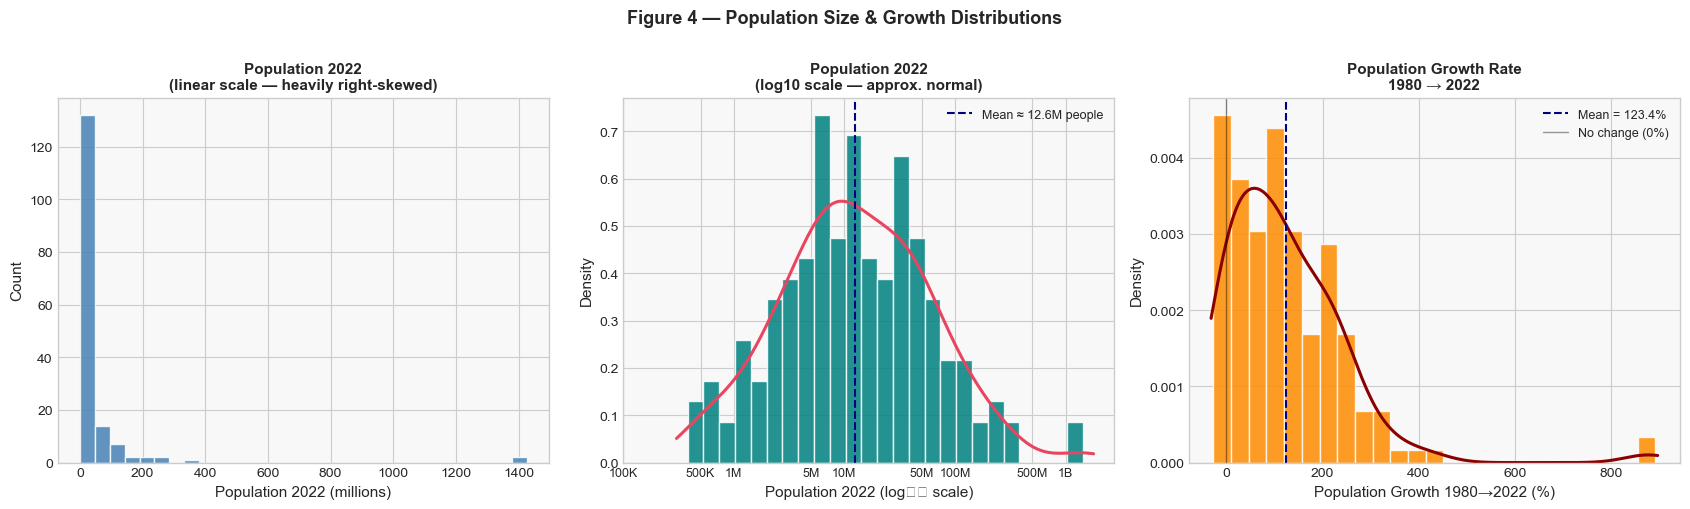

In [30]:
pop    = df_combined['Pop_2022'].dropna() / 1e6   # millions
logpop = df_combined['Log_Pop_2022'].dropna()
growth = df_combined['Pop_growth_pct'].dropna()

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Linear (shows extreme skew)
axes[0].hist(pop, bins=30, color='steelblue', edgecolor='white', alpha=0.85)
axes[0].set_xlabel('Population 2022 (millions)', fontsize=11)
axes[0].set_ylabel('Count', fontsize=11)
axes[0].set_title('Population 2022\n(linear scale — heavily right-skewed)', fontsize=11, fontweight='bold')

# Log scale
axes[1].hist(logpop, bins=25, color='teal', edgecolor='white', alpha=0.85, density=True)
kde_x = np.linspace(logpop.min() - 0.1, logpop.max() + 0.1, 300)
axes[1].plot(kde_x, stats.gaussian_kde(logpop)(kde_x), color=ACCENT, lw=2.2)
axes[1].axvline(logpop.mean(), color='navy', lw=1.5, ls='--',
                label=f'Mean ≈ {10**logpop.mean()/1e6:.1f}M people')
axes[1].set_xticks([5, 5.7, 6, 6.7, 7, 7.7, 8, 8.7, 9])
axes[1].set_xticklabels(['100K','500K','1M','5M','10M','50M','100M','500M','1B'], fontsize=9)
axes[1].set_xlabel('Population 2022 (log₁₀ scale)', fontsize=11)
axes[1].set_ylabel('Density', fontsize=11)
axes[1].set_title('Population 2022\n(log10 scale — approx. normal)', fontsize=11, fontweight='bold')
axes[1].legend(fontsize=9)

# Growth rate
axes[2].hist(growth, bins=25, color='darkorange', edgecolor='white', alpha=0.85, density=True)
kde_x2 = np.linspace(growth.min() - 5, growth.max() + 5, 300)
axes[2].plot(kde_x2, stats.gaussian_kde(growth)(kde_x2), color='darkred', lw=2.2)
axes[2].axvline(growth.mean(), color='navy',  lw=1.5, ls='--', label=f'Mean = {growth.mean():.1f}%')
axes[2].axvline(0,             color='black', lw=1.0, ls='-',  alpha=0.4, label='No change (0%)')
axes[2].set_xlabel('Population Growth 1980→2022 (%)', fontsize=11)
axes[2].set_ylabel('Density', fontsize=11)
axes[2].set_title('Population Growth Rate\n1980 → 2022', fontsize=11, fontweight='bold')
axes[2].legend(fontsize=9)

plt.suptitle('Figure 4 — Population Size & Growth Distributions', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## Skriv om population distribution og udvikling. Fra Claude:

Population size is **extremely right-skewed on a linear scale** — a handful of giants (China, India, USA) dwarf
the rest. On a log₁₀ scale the distribution becomes approximately normal, confirming that the *order of magnitude*
of a country's population varies smoothly. This is why `Log_Pop_2022` is the right variable to use in scatter
plots and regressions.

Population growth 1980→2022 is right-skewed with a mean around +120%. A small number of countries have actually
**shrunk** (e.g. Bulgaria, Albania, Ukraine) — mostly in Eastern Europe following post-Soviet emigration.

### 3.5 Correlation matrix

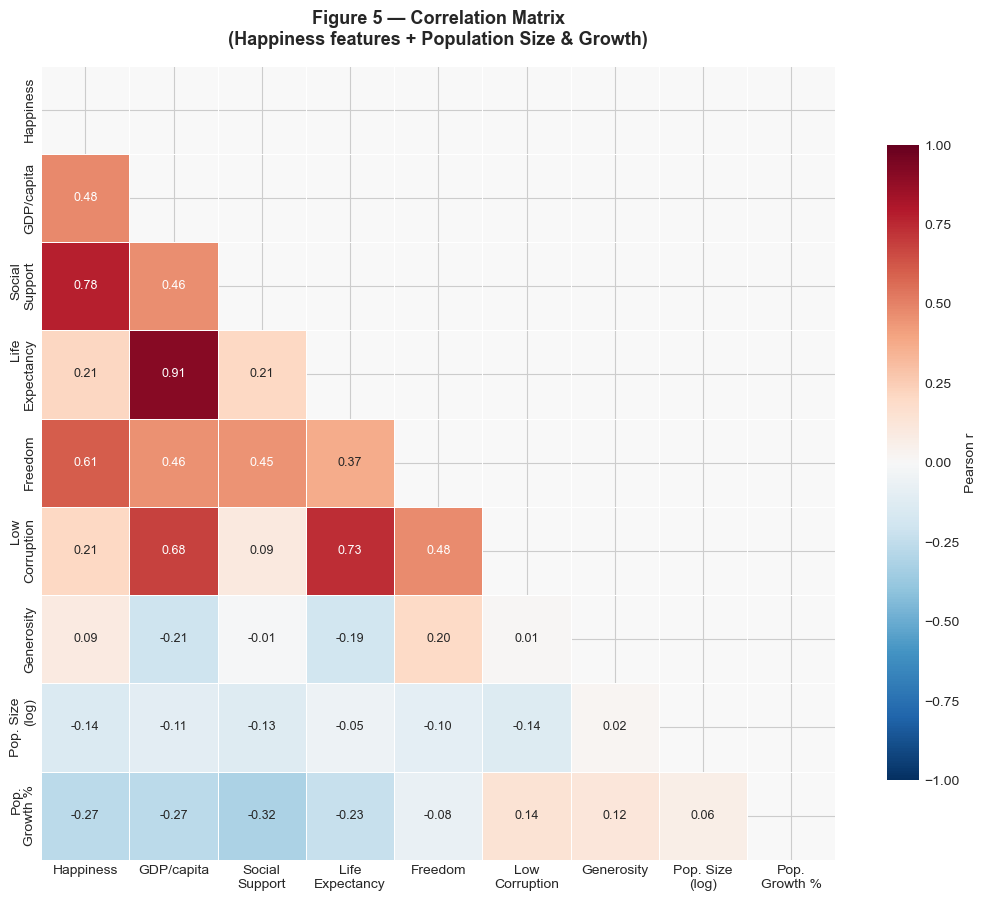

In [31]:
corr_cols = [
    'Happiness Score', 'GDP per Capita', 'Social Support',
    'Healthy Life Expectancy', 'Freedom', 'Perceptions of Corruption',
    'Generosity', 'Log_Pop_2022', 'Pop_growth_pct'
]
corr_labels = [
    'Happiness', 'GDP/capita', 'Social\nSupport', 'Life\nExpectancy',
    'Freedom', 'Low\nCorruption', 'Generosity', 'Pop. Size\n(log)', 'Pop.\nGrowth %'
]
corr_matrix = df_combined[corr_cols].corr()
mask        = np.triu(np.ones_like(corr_matrix, dtype=bool))

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='RdBu_r', center=0, vmin=-1, vmax=1,
    linewidths=0.5, linecolor='white', square=True,
    xticklabels=corr_labels, yticklabels=corr_labels,
    annot_kws={'size': 9}, ax=ax,
    cbar_kws={'shrink': 0.8, 'label': 'Pearson r'}
)
ax.set_title(
    'Figure 5 — Correlation Matrix\n(Happiness features + Population Size & Growth)',
    fontsize=13, fontweight='bold', pad=15
)
ax.tick_params(labelsize=10)
plt.tight_layout()
plt.show()

## Skriv noget om feature sammenhæng. Fra Claude:

Key takeaways:
- **GDP per Capita**, **Social Support**, and **Healthy Life Expectancy** are the strongest predictors of
  happiness (r > 0.7), consistent with the academic literature on the topic.
- **Population size (log)** shows a **weak negative correlation** with happiness (r ≈ −0.2 to −0.3) — small
  initial support for our hypothesis, but clearly not the dominant driver.
- **Population growth %** shows a **stronger negative correlation** with happiness (r ≈ −0.4) — countries
  that have grown rapidly since 1980 tend to be less happy, which may reflect rapid demographic transitions in
  lower-income regions.
- The two population variables are themselves only weakly correlated, confirming they capture different
  aspects of our hypothesis.

### 3.5 Happiness vs. Population Size

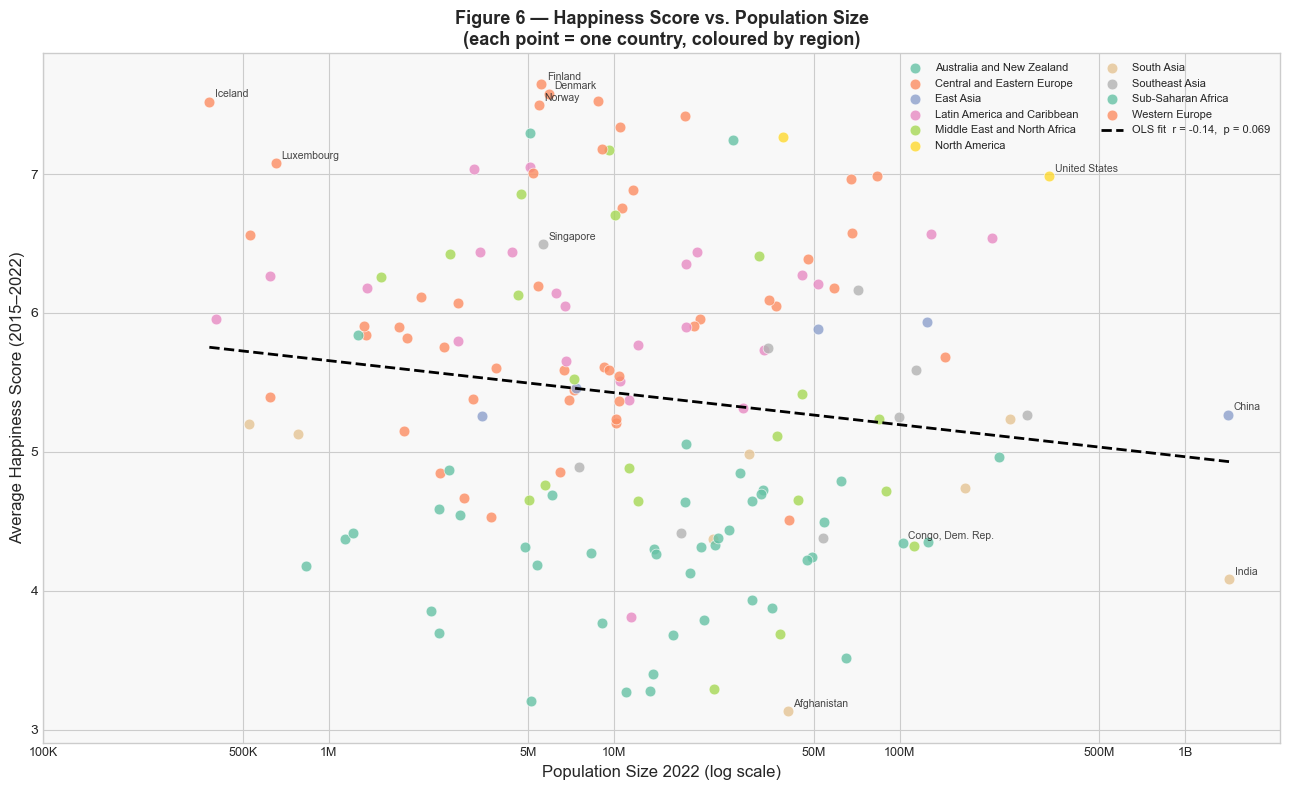

In [33]:
fig, ax = plt.subplots(figsize=(13, 8))

for region, grp in df_combined.groupby('Region'):
    ax.scatter(grp['Log_Pop_2022'], grp['Happiness Score'],
               label=region, s=60, alpha=0.8, edgecolors='white', lw=0.5)

# OLS regression line
x = df_combined['Log_Pop_2022'].dropna()
y = df_combined.loc[x.index, 'Happiness Score']
slope, intercept, r, p, se = stats.linregress(x, y)
x_line = np.linspace(x.min(), x.max(), 200)
ax.plot(x_line, intercept + slope * x_line, color='black', lw=2, ls='--',
        label=f'OLS fit  r = {r:.2f},  p = {p:.3f}')

# Annotate notable countries
notable = ['Finland', 'Denmark', 'Iceland', 'Norway', 'Afghanistan',
           'Congo, Dem. Rep.', 'China', 'India', 'United States',
           'Luxembourg', 'Singapore']
for _, row in df_combined[df_combined['Country'].isin(notable)].iterrows():
    ax.annotate(row['Country'],
                (row['Log_Pop_2022'], row['Happiness Score']),
                fontsize=7.5, xytext=(4, 3), textcoords='offset points', alpha=0.85)

ax.set_xticks([5, 5.7, 6, 6.7, 7, 7.7, 8, 8.7, 9])
ax.set_xticklabels(['100K', '500K', '1M', '5M', '10M', '50M', '100M', '500M', '1B'], fontsize=9)
ax.set_xlabel('Population Size 2022 (log scale)', fontsize=12)
ax.set_ylabel('Average Happiness Score (2015–2022)', fontsize=12)
ax.set_title(
    'Figure 6 — Happiness Score vs. Population Size\n'
    '(each point = one country, coloured by region)',
    fontsize=13, fontweight='bold'
)
ax.legend(fontsize=8, loc='upper right', ncol=2)
plt.tight_layout()
plt.show()

### Skriv noget om sammenhæng
The scatter plot shows a **modest downward trend** — larger populations tend to score slightly lower on happiness.
However, the relationship is far from deterministic: several large countries (USA, Germany) score well, while
several small countries (e.g. in Sub-Saharan Africa) score poorly. The negative slope is largely driven by
**region**: African countries are both populous-growth nations and low-happiness nations, while Western European
countries are small and happy.

This motivates the deeper analysis on the website: **controlling for region and GDP, does population size still
predict happiness?**

### 3.5 Happiness vs. Population Growth

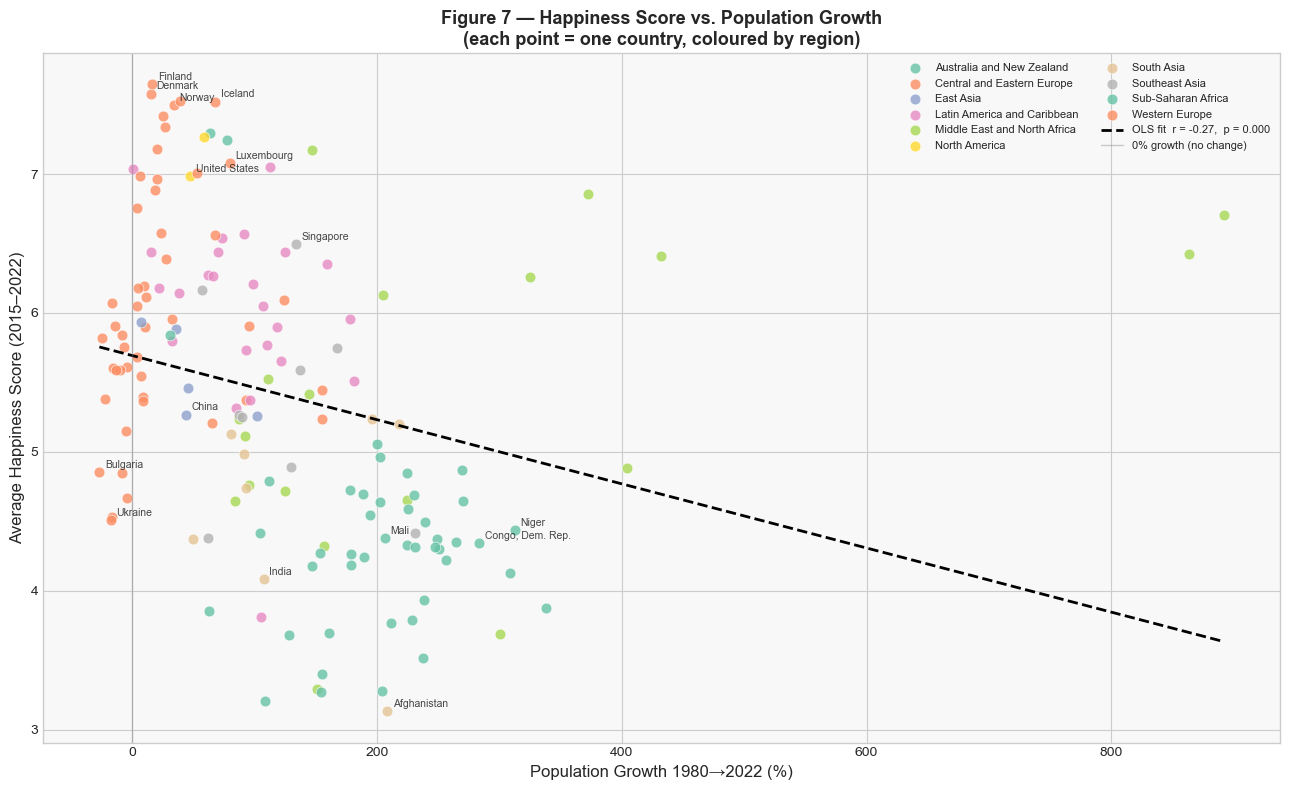

In [37]:
fig, ax = plt.subplots(figsize=(13, 8))

for region, grp in df_combined.groupby('Region'):
    ax.scatter(grp['Pop_growth_pct'], grp['Happiness Score'],
               label=region, s=60, alpha=0.8, edgecolors='white', lw=0.5)

# OLS regression line
x = df_combined['Pop_growth_pct'].dropna()
y = df_combined.loc[x.index, 'Happiness Score']
slope, intercept, r, p, se = stats.linregress(x, y)
x_line = np.linspace(x.min(), x.max(), 200)
ax.plot(x_line, intercept + slope * x_line, color='black', lw=2, ls='--',
        label=f'OLS fit  r = {r:.2f},  p = {p:.3f}')

# Annotate notable countries
notable = ['Finland', 'Denmark', 'Iceland', 'Norway', 'Afghanistan',
           'Congo, Dem. Rep.', 'China', 'India', 'United States',
           'Luxembourg', 'Singapore', 'Ukraine', 'Bulgaria', 'Niger', 'Mali']
for _, row in df_combined[df_combined['Country'].isin(notable)].iterrows():
    ax.annotate(row['Country'],
                (row['Pop_growth_pct'], row['Happiness Score']),
                fontsize=7.5, xytext=(4, 3), textcoords='offset points', alpha=0.85)

ax.axvline(0, color='grey', lw=1, ls='-', alpha=0.4, label='0% growth (no change)')
ax.set_xlabel('Population Growth 1980→2022 (%)', fontsize=12)
ax.set_ylabel('Average Happiness Score (2015–2022)', fontsize=12)
ax.set_title(
    'Figure 7 — Happiness Score vs. Population Growth\n'
    '(each point = one country, coloured by region)',
    fontsize=13, fontweight='bold'
)
ax.legend(fontsize=8, loc='upper right', ncol=2)
plt.tight_layout()
plt.show()

Samme plot men med outliers (meget emigigrationsarbejde) fjernet. Sørg for at argumenter for hvorfor de er fjernet.

Lande i plot: 159  (fjernet: ['United Arab Emirates', 'Qatar', 'Saudi Arabia'])


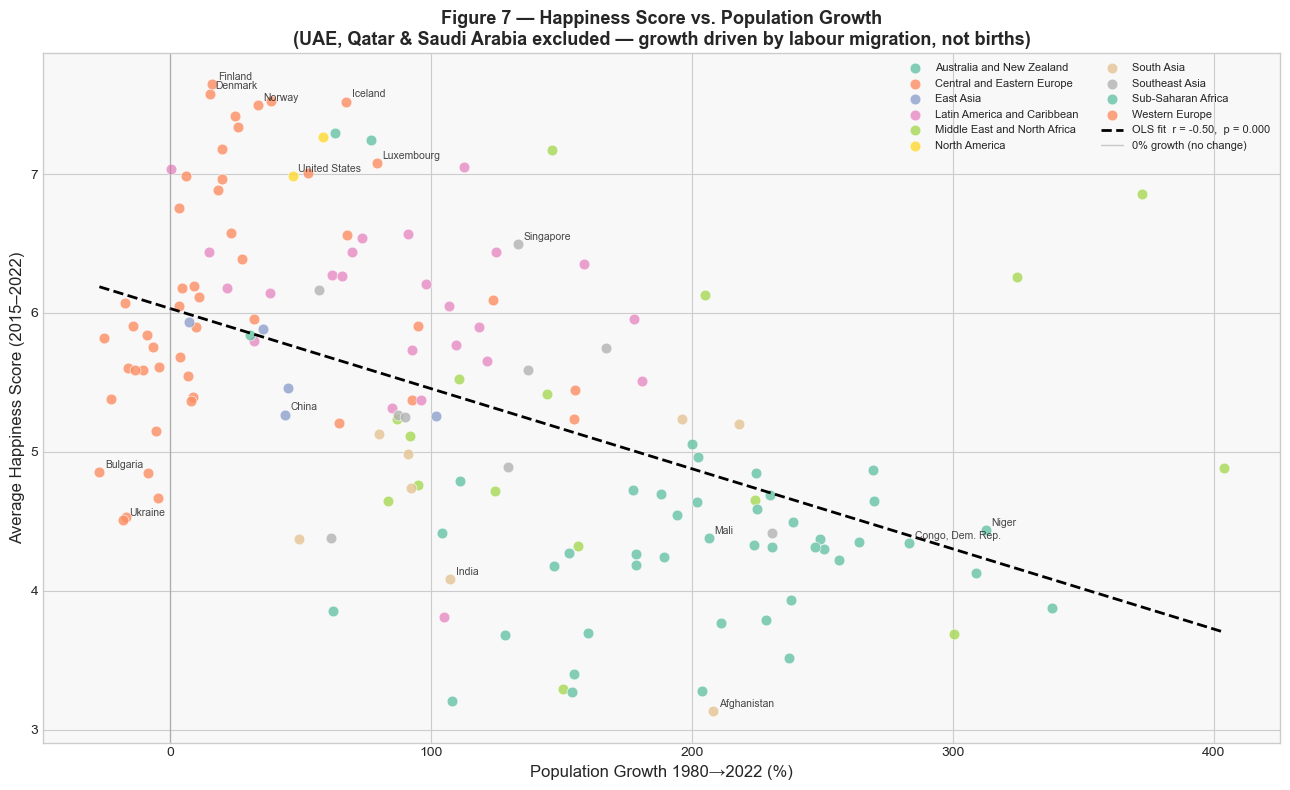

In [38]:
# UAE, Qatar og Saudi Arabia fjernes: deres ekstreme vækst skyldes
# arbejdsmigration, ikke organisk befolkningstilvækst, og forvrider regressionen
migration_outliers = ['United Arab Emirates', 'Qatar', 'Saudi Arabia']
df_plot = df_combined[~df_combined['Country'].isin(migration_outliers)].copy()

print(f"Lande i plot: {len(df_plot)}  (fjernet: {migration_outliers})")

fig, ax = plt.subplots(figsize=(13, 8))

for region, grp in df_plot.groupby('Region'):
    ax.scatter(grp['Pop_growth_pct'], grp['Happiness Score'],
               label=region, s=60, alpha=0.8, edgecolors='white', lw=0.5)

# OLS regression line
x = df_plot['Pop_growth_pct'].dropna()
y = df_plot.loc[x.index, 'Happiness Score']
slope, intercept, r, p, se = stats.linregress(x, y)
x_line = np.linspace(x.min(), x.max(), 200)
ax.plot(x_line, intercept + slope * x_line, color='black', lw=2, ls='--',
        label=f'OLS fit  r = {r:.2f},  p = {p:.3f}')

# Annotate notable countries
notable = ['Finland', 'Denmark', 'Iceland', 'Norway', 'Afghanistan',
           'Congo, Dem. Rep.', 'China', 'India', 'United States',
           'Luxembourg', 'Singapore', 'Ukraine', 'Bulgaria', 'Niger', 'Mali']
for _, row in df_plot[df_plot['Country'].isin(notable)].iterrows():
    ax.annotate(row['Country'],
                (row['Pop_growth_pct'], row['Happiness Score']),
                fontsize=7.5, xytext=(4, 3), textcoords='offset points', alpha=0.85)

ax.axvline(0, color='grey', lw=1, ls='-', alpha=0.4, label='0% growth (no change)')
ax.set_xlabel('Population Growth 1980→2022 (%)', fontsize=12)
ax.set_ylabel('Average Happiness Score (2015–2022)', fontsize=12)
ax.set_title(
    'Figure 7 — Happiness Score vs. Population Growth\n'
    '(UAE, Qatar & Saudi Arabia excluded — growth driven by labour migration, not births)',
    fontsize=13, fontweight='bold'
)
ax.legend(fontsize=8, loc='upper right', ncol=2)
plt.tight_layout()
plt.show()

## Skriv noget om plottet
Korrelationen er r = −0.27 (p = 0.0005) — svagt men statistisk signifikant negativt. Lande med hurtig befolkningsvækst er generelt mindre lykkelige. Det er faktisk en lidt svagere sammenhæng end vi så i korrelationsmatricen, fordi det store outlier-cluster af afrikanske lande med 200–800% vækst og lav lykke trækker linjen ned, men med stor spredning. Ukraine og Bulgaria er interessante undtagelser i venstre side — de har haft negativ vækst (folk er flygtet/emigreret) og scorer middelmådigt på lykke.

---
## 4. Genre
<a id='4-genre'></a>

### 4.1 Choice of genre

Beskriv hvilken genre (jf. Segel & Heer, 2010) I har valgt til jeres data story, og *hvorfor* den er den rigtige til netop jeres fortælling.

**Genre:** *(fx Magazine Style / Annotated Chart / Slideshow / Partitioned Poster / Flow Chart / Comic Strip / Film/Animation)*

**Begrundelse:** ...

---

### 4.2 Visual Narrative (Figure 7 Segel & Heer)

Beskriv hvilke værktøjer I bruger fra de 3 kategorier, og begrund valget:

| Kategori | Valgte værktøjer | Begrundelse |
|----------|-----------------|-------------|
| **Visual Structuring** | *fx Establishing Shot, Consistent Visual Platform* | ... |
| **Highlighting** | *fx Feature Arrow, Close-ups, Motion* | ... |
| **Transition Guidance** | *fx Animated Transitions, Continuity Editing* | ... |

### 4.3 Narrative Structure (Figure 7 Segel & Heer)

| Kategori | Valgte værktøjer | Begrundelse |
|----------|-----------------|-------------|
| **Ordering** | *fx Random Access, Linear* | ... |
| **Interactivity** | *fx Hover Highlighting, Filtering, Navigation Buttons* | ... |
| **Messaging** | *fx Captions, Annotations, Summary* | ... |

---
## 5. Visualizations
<a id='5-visualizations'></a>

For hver visualisering på jeres website: forklar valget og hvorfor den er den rigtige til historien.

### 5.1 [Navn på visualisering 1]

**Type:** *(fx choropleth map, scatter plot, time series, ...)*

**Formål:** ...

**Begrundelse:** ...

In [ ]:
# Kode til visualisering 1
# fig, ax = plt.subplots(figsize=(10, 6))
# ...

### 5.2 [Navn på visualisering 2]

**Type:** ...

**Formål:** ...

**Begrundelse:** ...

In [ ]:
# Kode til visualisering 2

### 5.3 [Interaktiv visualisering]

**Type:** *(fx Bokeh, Plotly, D3, Folium, ...)*

**Formål:** ...

**Begrundelse:** ...

In [ ]:
# Kode til interaktiv visualisering
# import plotly.express as px
# ...

---
## 6. Discussion
<a id='6-discussion'></a>

### 6.1 Hvad gik godt?

...

### 6.2 Hvad mangler / kan forbedres?

...

### 6.3 Begrænsninger

Overvej kritisk:
- Datasættets begrænsninger (bias, manglende data, tidsperiode)
- Metodiske forbehold
- Hvad ville I gøre anderledes med mere tid?

---
## 7. Contributions
<a id='7-contributions'></a>

| Group member | Primarily responsibility |
|-------------|------------------------|
| **Karen Stentoft** (s253843) | ... |
| **Frida Pilegaard Frandsen** (s253842) | ... |

*Both group members took part in the entire project.*

---
## 8. References
<a id='8-references'></a>

Følg akademisk standard for referencer (fx APA eller IEEE).

[1] Segel, E., & Heer, J. (2010). Narrative visualization: Telling stories with data. *IEEE Transactions on Visualization and Computer Graphics*, 16(6), 1139–1148.

[2] [Datasæt-reference her]

[3] [Øvrige kilder her]

---